## 3️⃣Phase 3: Analyse, Visualise & Report  
#### 1. distributions  
#### 2. boxplots  
#### 3. correlations  
#### 4. relationships  
#### 5. groupby  
#### 6. math basics

## 1} Imports

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2} Load

In [62]:
# Load features dataset

df = pd.read_csv("/content/features_DataSet.csv")

df.head()

print()

print("Shape:", df.shape)


Shape: (2344, 114)


## 3} Distributions

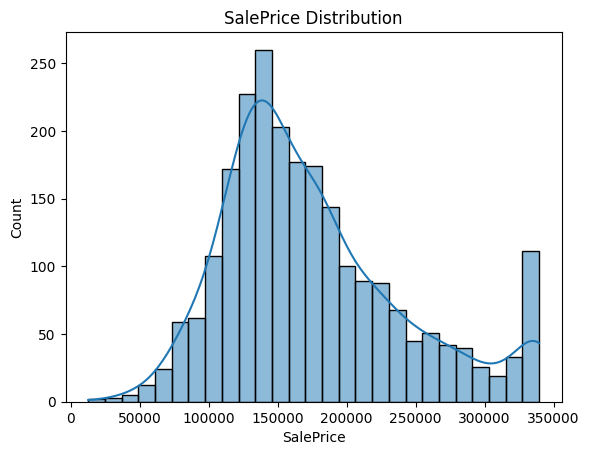

In [63]:
# Distribution of SalePrice

sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

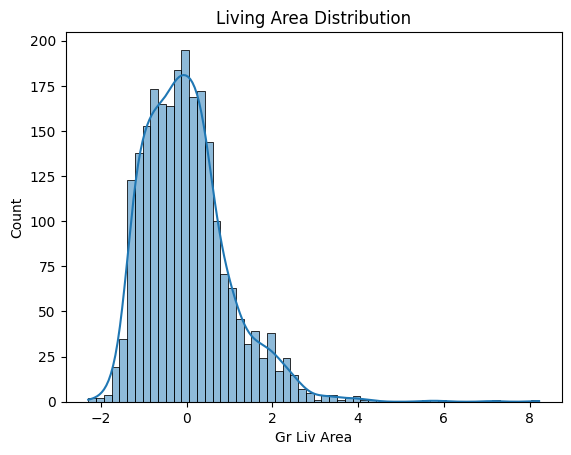

In [64]:
# Distribution of living area

sns.histplot(df["Gr Liv Area"], kde=True)
plt.title("Living Area Distribution")
plt.show()

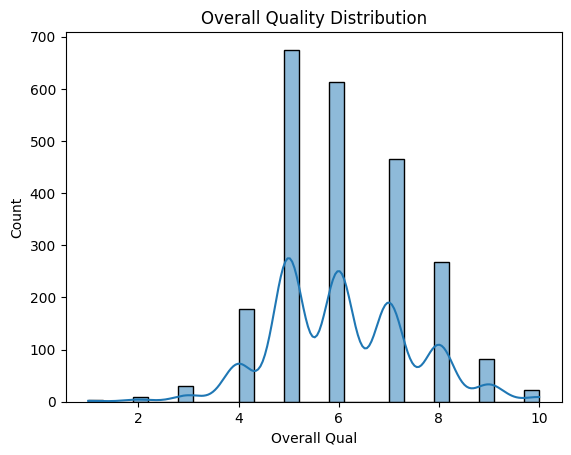

In [65]:
# Distribution of house quality

sns.histplot(df["Overall Qual"], kde=True)
plt.title("Overall Quality Distribution")
plt.show()

#### Insight

> - SalePrice is slightly skewed  
> - Most houses have medium quality  
> - Very large houses are less common

## 4} Boxplots

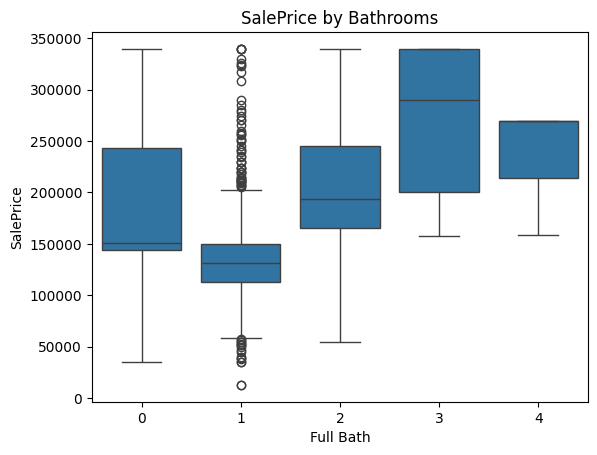

In [66]:
# SalePrice vs Full Bath

sns.boxplot(x=df["Full Bath"], y=df["SalePrice"])
plt.title("SalePrice by Bathrooms")
plt.show()

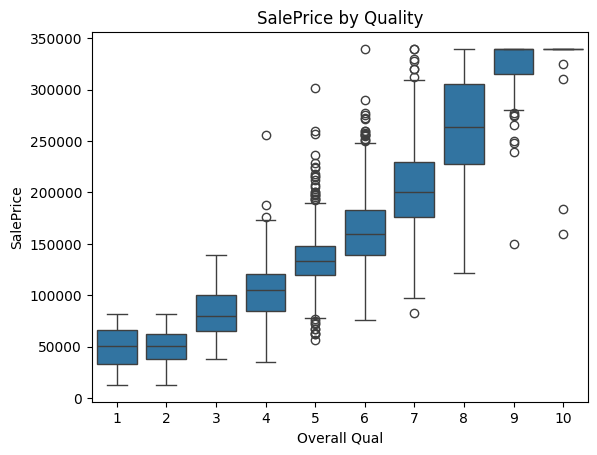

In [67]:
# SalePrice vs Overall Quality

sns.boxplot(x=df["Overall Qual"], y=df["SalePrice"])
plt.title("SalePrice by Quality")
plt.show()

#### Insight

> - Higher quality houses have higher prices  
> - More features increase the price  
> - There are some outliers

## 5} Correlation

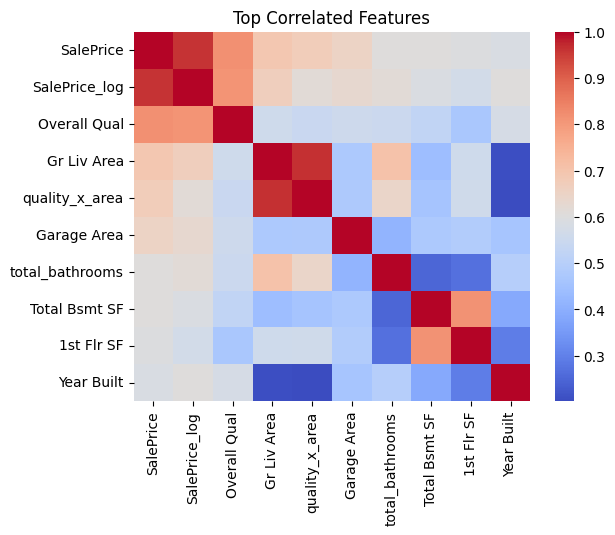

In [68]:
# Top correlations with SalePrice

corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

top_corr = corr.head(10)

sns.heatmap(df[top_corr.index].corr(), cmap="coolwarm")
plt.title("Top Correlated Features")
plt.show()

#### Insight

> - SalePrice is strongly related to quality and area  
> - some features have weak correlation  
> - important features can help prediction

## 6} Relationships

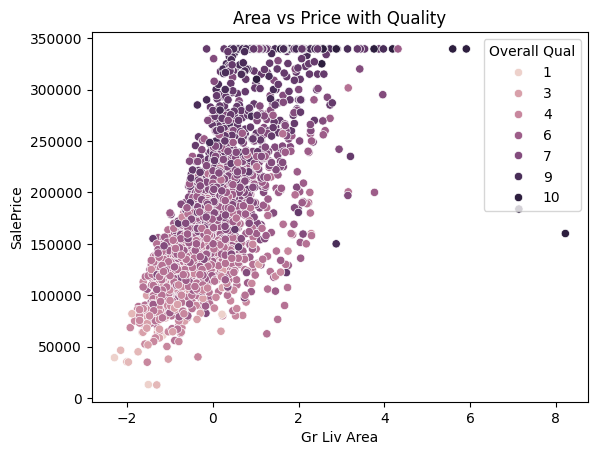

In [69]:
# Relationship between area and price

sns.scatterplot(x=df["Gr Liv Area"], y=df["SalePrice"], hue=df["Overall Qual"])
plt.title("Area vs Price with Quality")
plt.show()

## 7} Groupby

In [70]:
# Mean SalePrice by Quality

group = df.groupby("Overall Qual")["SalePrice"].mean().sort_values(ascending=False)

group.head()

,SalePrice
Overall Qual,
10,322265.909091
9,320945.234568
8,264197.310861
7,203876.511828
6,162389.595432


## 8} Math Basics

In [71]:
# Mean and std using numpy

mean = np.mean(df["SalePrice"])
std = np.std(df["SalePrice"])

print("Mean:", mean)
print("Std:", std)

Mean: 175384.10281569965
Std: 66449.29557254244


In [72]:
# Standardization manually

z = (df["SalePrice"] - mean) / std

z.head()

,SalePrice
0,-0.351909
1,0.144710
2,-1.107372
3,-1.284951
4,-1.216478


In [73]:
# Select numeric columns only

num_df = df.select_dtypes(include=[np.number])

high = num_df.loc[df["SalePrice"].idxmax()]
low = num_df.loc[df["SalePrice"].idxmin()]

cos_sim = np.dot(high, low) / (norm(high) * norm(low))

print("Cosine similarity:", cos_sim)

Cosine similarity: 0.9999997113847447


In [74]:
# Probability example

high_quality = df[df["Overall Qual"] >= 8]

prob = (high_quality["SalePrice"] > 200000).mean()

print("Probability:", prob)

Probability: 0.9108108108108108


## done🌟

> - visualized data using charts  
>
> - explored relationships between features  
> - analyzed correlations  
> - compared groups  
> - applied math concepts